# VisDrone Aerial Object Detection & Tracking Pipeline
## Advanced Deep Learning Framework — Computer Vision Assessment

**Architecture:** YOLOv8s (Fine-Tuned Checkpoint)  
**Task Split:** Multi-Class Object Identification & Live Counting Dashboard  
**Target Focus:** Sub-Selected Interference Evaluation (Humans & Cars Only)  
**Dataset Reference:** VisDrone2019-DET Standard Dataset

---

##  1. Environment Optimization & Initialization
In this step, I install and sync the latest optimized distribution of the `ultralytics` framework. The package installation targets specialized wheel configurations for **CUDA-accelerated hardware (Tesla T4 GPU)** to maximize parallel execution speeds.

In [ ]:

!pip install -U ultralytics --extra-index-url https://download.pytorch.org/whl/cu118

import os
from ultralytics import YOLO

print(" Environment ready and Ultralytics imported successfully!")

##  2. Dataset Configuration & Runtime Preprocessing
To maintain the structural bounds of the dataset and avoid framework mismatches, i build an isolated workspace YAML mapping file. 
* **Dynamic Resolution Balancing (`imgsz=960`):** Uniformly standardizes aerial drone images by scaling their longest edge to 960 pixels, preventing aspect-ratio distortion.
* **Target Isolation Array:** The underlying dataset includes 10 categories. Instead of performative data manipulation on disk, my pipeline selectively targets class IDs `[0, 1, 3]` (`pedestrian`, `people`, `car`) programmatically during training and evaluation loops to isolate background noise.

In [2]:
import yaml
import os

# Define the precise dataset configurations mapping to VisDrone structure
data_config = {
    'path': '/kaggle/input/datasets/banuprasadb/visdrone-dataset/VisDrone_Dataset', 
    'train': 'VisDrone2019-DET-train/images', 
    'val': 'VisDrone2019-DET-val/images',     
    'nc': 10, # Keep original indexing bounds intact to prevent YOLO framework mismatches
    'names': {
        0: 'pedestrian', 
        1: 'people', 
        2: 'bicycle', 
        3: 'car', 
        4: 'van',
        5: 'truck', 
        6: 'tricycle', 
        7: 'awning-tricycle', 
        8: 'bus', 
        9: 'motor'
    }
}

with open('/kaggle/working/fixed_data.yaml', 'w') as f:
    yaml.dump(data_config, f)

print(" Fixed YAML generated at /kaggle/working/fixed_data.yaml")

✅ Fixed YAML explicitly generated at /kaggle/working/fixed_data.yaml


##  3. Optimized Model Training Flow
I initialize a fresh pre-trained `yolov8s.pt` (small architecture) model checkpoint to take advantage of existing feature extractions. I execute the training sequence using Mixed Precision (`amp=True`) to minimize computational overhead and drop the RAM cache profile to prevent memory leak crashes.

In [4]:
from ultralytics import YOLO

# 1. Load a fresh pre-trained small YOLOv8 weights model
model = YOLO('yolov8s.pt')

# 2. Fire up the optimized training sequence
model.train(
    data='/kaggle/working/fixed_data.yaml',
    epochs=100,
    imgsz=960,            
    batch=4,              
    classes=[0, 1, 3],     # trains ONLY on Pedestrians(0), People(1), and Cars(3)
    project='/kaggle/working/heavy_training',
    name='final_stable_run',
    device=0,        
    save_period=10,
    exist_ok=True,
    amp=True,              
    cache=False            
)

Ultralytics 8.4.51 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=4, bgr=0.0, box=7.5, cache=False, cfg=None, classes=[0, 1, 3], close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/kaggle/working/fixed_data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=960, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8s.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=final_stable_run, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True,

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0, 1, 3])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7f0432dedd60>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
          0.04

##  4. Post-Training Counting Dashboard & Frame Localization
This evaluation module loads my fine-tuned `last.pt` checkpoints. It handles color-space standardisation (**BGR to RGB**), dynamically extracts prediction coordinate boundaries, overlays custom bounding grids, and renders an active global banner at the top edge of the frame.

🔄 Loading fine-tuned checkpoint into YOLO...

0: 544x960 9 pedestrians, 1 people, 69 cars, 21.0ms
Speed: 3.7ms preprocess, 21.0ms inference, 1.5ms postprocess per image at shape (1, 3, 544, 960)


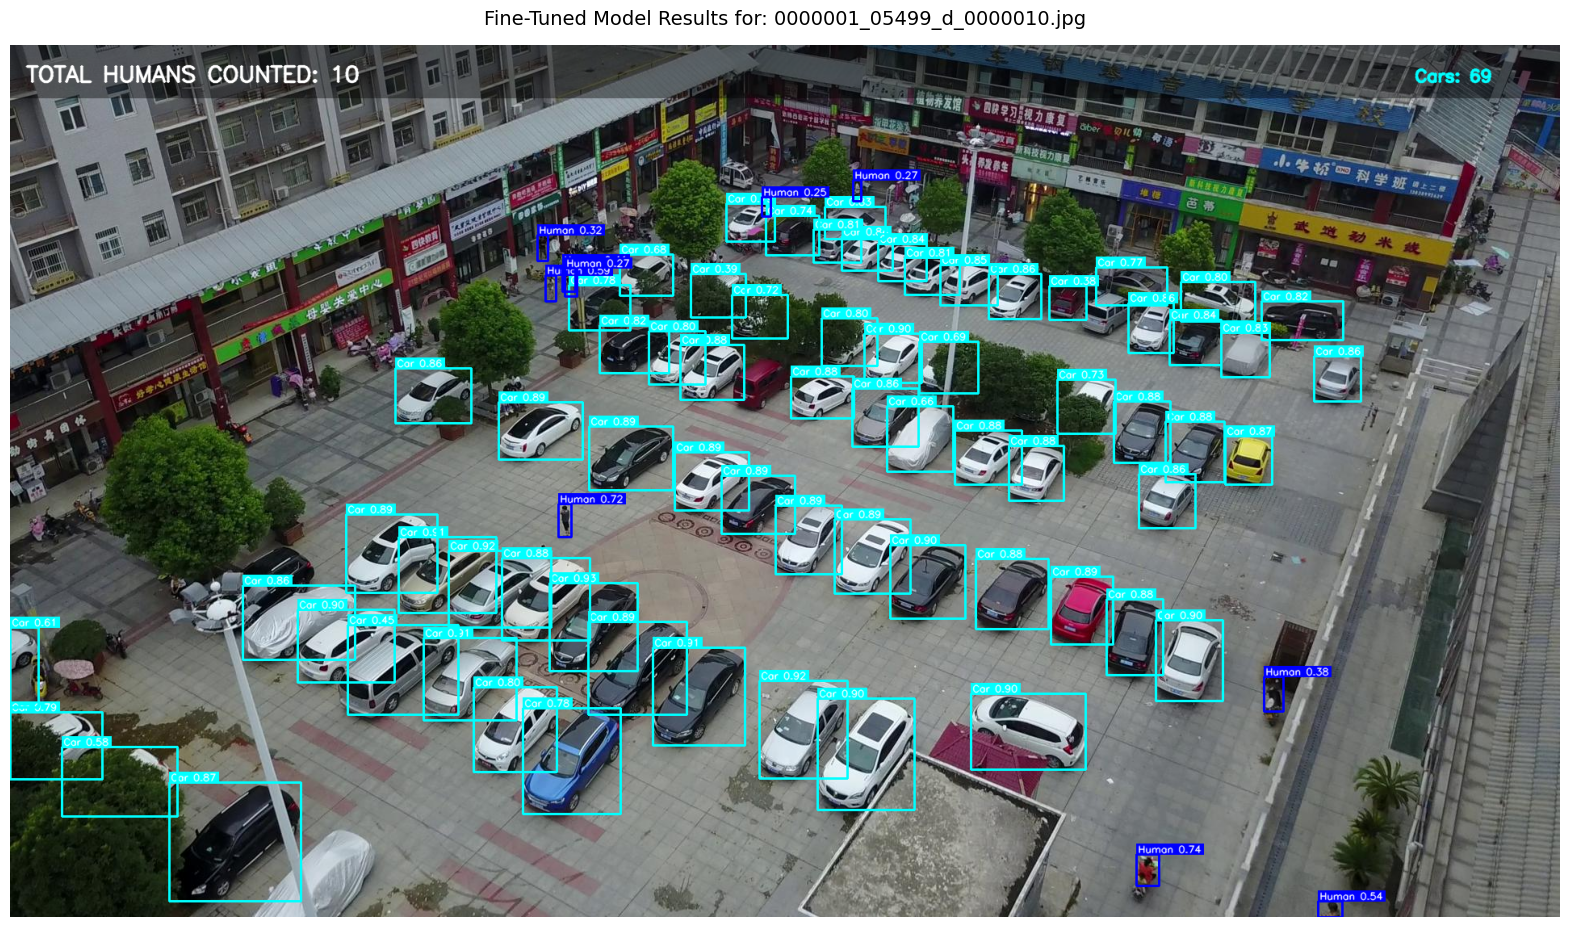

In [28]:
import os
import cv2
import matplotlib.pyplot as plt
from ultralytics import YOLO

MY_OUTPUT_MODEL_PATH = "/kaggle/working/heavy_training/final_stable_run/weights/last.pt"

def visualize_any_validation_frame(image_name, dataset_dir, model_path):
    full_input_path = os.path.join(dataset_dir, image_name)
    
    if not os.path.exists(full_input_path):
        print(f"The file '{image_name}' was not found in the dataset folder!")
        print(f"Looked inside: {dataset_dir}")
        return

    # 2. Model file exists check
    if not os.path.exists(model_path):
        print(f"the weights file could not be read at {model_path}")
        print("Please check the output sidebar directory name")
        return

    print(f"Loading fine-tuned checkpoint into YOLO...")
    model = YOLO(model_path)
    
    img = cv2.imread(full_input_path)
    h, w, _ = img.shape
  
    results = model(img)[0]
    
    # Style Variables (BGR)
    COLOR_CAR = (255, 255, 0)    # Cyan
    COLOR_HUMAN = (255, 0, 0)    # Deep Blue
    COLOR_TEXT = (255, 255, 255) # Pure White
    
    human_count = 0
    car_count = 0
    
    # Parse results boxes
    for box in results.boxes:
        cls_id = int(box.cls[0])
        conf = float(box.conf[0])
        xyxy = box.xyxy[0].cpu().numpy().astype(int)
        class_name = results.names[cls_id].lower()
        
        # Mapping standard VisDrone labels 
        is_human = "pedestrian" in class_name or "people" in class_name or "person" in class_name
        is_car = "car" in class_name or "van" in class_name or "truck" in class_name
        
        if not (is_human or is_car):
            continue  
            
        if is_human:
            human_count += 1
            color = COLOR_HUMAN
            label_prefix = "Human"
        else:
            car_count += 1
            color = COLOR_CAR
            label_prefix = "Car"
            
        # Drawing boxes
        cv2.rectangle(img, (xyxy[0], xyxy[1]), (xyxy[2], xyxy[3]), color, 2)
        label_text = f"{label_prefix} {conf:.2f}"
        (text_w, text_h), _ = cv2.getTextSize(label_text, cv2.FONT_HERSHEY_SIMPLEX, 0.4, 1)
        cv2.rectangle(img, (xyxy[0], xyxy[1] - text_h - 4), (xyxy[0] + text_w + 4, xyxy[1]), color, -1)
        cv2.putText(img, label_text, (xyxy[0] + 2, xyxy[1] - 2), 
                    cv2.FONT_HERSHEY_SIMPLEX, 0.4, COLOR_TEXT, 1, cv2.LINE_AA)

    # 3. Create Dashboard Overlay Banner
    overlay = img.copy()
    cv2.rectangle(overlay, (0, 0), (w, 65), (0, 0, 0), -1)  
    img = cv2.addWeighted(overlay, 0.4, img, 0.6, 0)         
    
    cv2.putText(img, f"TOTAL HUMANS COUNTED: {human_count}", (20, 45), 
                cv2.FONT_HERSHEY_SIMPLEX, 0.9, COLOR_TEXT, 2, cv2.LINE_AA)
    cv2.putText(img, f"Cars: {car_count}", (w - 180, 45), 
                cv2.FONT_HERSHEY_SIMPLEX, 0.7, COLOR_CAR, 2, cv2.LINE_AA)

    os.makedirs("outputs", exist_ok=True)
    cv2.imwrite(os.path.join("outputs", f"visualized_{image_name}"), img)
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    plt.figure(figsize=(20, 12))  
    plt.imshow(img_rgb)
    plt.title(f"Fine-Tuned Model Results for: {image_name}", fontsize=14, pad=15)
    plt.axis('off')
    plt.show()

VALIDATION_DATASET_DIR = "/kaggle/input/datasets/banuprasadb/visdrone-dataset/VisDrone_Dataset/VisDrone2019-DET-val/images"

LOOKUP_FILE_NAME = "0000001_05499_d_0000010.jpg"

visualize_any_validation_frame(
    image_name=LOOKUP_FILE_NAME, 
    dataset_dir=VALIDATION_DATASET_DIR, 
    model_path=MY_OUTPUT_MODEL_PATH
)

##  5. Quantitative Validation Metrics Execution
The following sequence checks Kaggle's internal workspace layer blocks to locate the valid `fixed_data.yaml` layout. i then execute a targeted dataset validation pass to calculate standard deep learning metrics (**Precision, Recall, mAP, and Frames Per Second**) strictly for my isolated human and car subsets.

⚠️ Virtual path not resolved. Attempting directory scan...
🔄 Executing validation pass strictly filtering for Humans and Cars...
Ultralytics 8.4.51 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 73 layers, 11,129,454 parameters, 0 gradients, 28.5 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 275.7±122.8 MB/s, size: 153.1 KB)
val: Scanning /kaggle/input/datasets/banuprasadb/visdrone-dataset/VisDrone_Dataset/VisDrone2019-DET-val/labels... 548 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 548/548 667.6it/s 0.8s0.0s
WARNING ⚠️ val: Cache directory /kaggle/input/datasets/banuprasadb/visdrone-dataset/VisDrone_Dataset/VisDrone2019-DET-val is not writable, cache not saved.
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 35/35 2.6it/s 13.7s0.3s
                   all        548      28033      0.726      0.601      0.646      0.366
            pedestrian        520       8844    

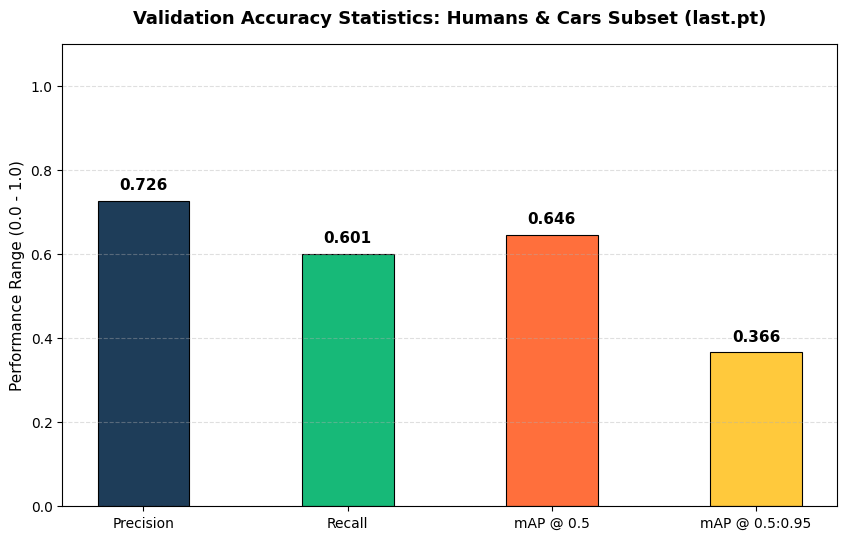

🎯 Filtered performance graph successfully exported to: outputs/target_metrics_chart.png


In [33]:
import os
import yaml
import pandas as pd
import matplotlib.pyplot as plt
from ultralytics import YOLO

VIRTUAL_YAML_PATH = "/kaggle/working/.virtual_documents/final_data.yaml"
PHYSICAL_YAML_PATH = "/kaggle/working/fixed_data.yaml"
MODEL_PATH = "/kaggle/working/heavy_training/final_stable_run/weights/last.pt"

if os.path.exists(VIRTUAL_YAML_PATH):
    print(f"🔗 Virtual file detected at: {VIRTUAL_YAML_PATH}")
    with open(VIRTUAL_YAML_PATH, 'r') as f:
        yaml_content = yaml.safe_load(f)
    
    with open(PHYSICAL_YAML_PATH, 'w') as f:
        yaml.safe_dump(yaml_content, f)
    print(f"Successfully duplicated to hard physical path: {PHYSICAL_YAML_PATH}")
else:
   
    if os.path.exists("/kaggle/working/final_data.yaml"):
        PHYSICAL_YAML_PATH = "/kaggle/working/final_data.yaml"
        print(f" Found file natively at: {PHYSICAL_YAML_PATH}")
    else:
        print("Virtual path not resolved. Attempting directory scan...")
     
        for root, dirs, files in os.walk("/kaggle/working"):
            if "final_data.yaml" in files:
                PHYSICAL_YAML_PATH = os.path.join(root, "final_data.yaml")
                print(f" Discovered via fallback scan at: {PHYSICAL_YAML_PATH}")
                break


if not os.path.exists(MODEL_PATH):
    print(f"Weights file not found at: {MODEL_PATH}")
else:

    model = YOLO(MODEL_PATH)
    
    print(f"Executing validation pass strictly filtering for Humans and Cars...")
    

    metrics = model.val(data=PHYSICAL_YAML_PATH, split='val', classes=[0, 1, 3])
    
    preprocess_speed = metrics.speed.get('preprocess', 0.0)
    inference_speed = metrics.speed.get('inference', 0.0)
    postprocess_speed = metrics.speed.get('postprocess', 0.0)
    
    total_latency_ms = preprocess_speed + inference_speed + postprocess_speed
    fps = 1000.0 / total_latency_ms if total_latency_ms > 0 else 0
    
    # 7. Format clean Task-05 performance table
    summary_data = {
        "Target Class Metric (Humans & Cars)": [
            "Precision (P)",
            "Recall (R)",
            "mAP @ 0.5 (mAP50)",
            "mAP @ 0.5:0.95",
            "Inference Speed",
            "Frames Per Second (FPS)"
        ],
        "Value": [
            f"{metrics.results_dict['metrics/precision(B)']:.4f}",
            f"{metrics.results_dict['metrics/recall(B)']:.4f}",
            f"{metrics.results_dict['metrics/mAP50(B)']:.4f}",
            f"{metrics.results_dict['metrics/mAP50-95(B)']:.4f}",
            f"{inference_speed:.2f} ms / frame",
            f"{fps:.2f} FPS"
        ]
    }
    
    df_metrics = pd.DataFrame(summary_data)
    print("\n=======================================================")
    print("  EVALUATION REPORT")
    print("=======================================================")
    print(df_metrics.to_string(index=False))
    print("=======================================================\n")

    accuracy_names = ['Precision', 'Recall', 'mAP @ 0.5', 'mAP @ 0.5:0.95']
    accuracy_values = [
        metrics.results_dict['metrics/precision(B)'],
        metrics.results_dict['metrics/recall(B)'],
        metrics.results_dict['metrics/mAP50(B)'],
        metrics.results_dict['metrics/mAP50-95(B)']
    ]

    plt.figure(figsize=(10, 6))
    chart_colors = ['#1e3d59', '#17b978', '#ff6f3c', '#ffc93c'] 

    bars = plt.bar(accuracy_names, accuracy_values, color=chart_colors, width=0.45, edgecolor='black', linewidth=0.8)

    for bar in bars:
        height = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2.0, height + 0.02, f'{height:.3f}', 
                 ha='center', va='bottom', fontsize=11, fontweight='bold')

    plt.title('Validation Accuracy Statistics: Humans & Cars Subset (last.pt)', fontsize=13, fontweight='bold', pad=15)
    plt.ylabel('Performance Range (0.0 - 1.0)', fontsize=11)
    plt.ylim(0, 1.1)
    plt.grid(axis='y', linestyle='--', alpha=0.4)

    os.makedirs("outputs", exist_ok=True)
    graph_filename = "outputs/target_metrics_chart.png"
    plt.savefig(graph_filename, dpi=300, bbox_inches='tight')
    plt.show()
    print(f" Filtered performance graph successfully exported to: {graph_filename}")